In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Analysis dataset

The data used for this project come from: https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis

In [3]:
dataset = pd.read_csv("dataset.csv")

**1.1 Understanding the dataset**

In [4]:
dataset.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


The dataset contains 19 features and one label (exam_score). Since the exam score consists of continuous numerical values, this is a regression problem. There are 6 numerical features and 13 categorical features.

The 6 numerical features can be divided into 4 continuous features (Hours_Studied, Attendance, Sleep_Hours, Previous_Scores) and 2 discrete features (Tutoring_Sessions, Physical_Activity).

The 13 categorical features can be further divided as follows:
- Ordinal features (8): Parental_Involvement, Access_to_Resources, Motivation_Level, Family_Income, Teacher_Quality, Peer_Influence, Parental_Education_Level, Distance_from_Home
- Nominal feature (1): School_Type
- Binary features (4): Extracurricular_Activities, Internet_Access, Learning_Disabilities, Gender

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

The dataset contains 6,607 entries. All feature types are correct, so no type handling is needed during preprocessing. However, there are missing values in Teacher_Quality, Parental_Education_Level, and Distance_from_Home, which need to be properly handled.

In [6]:
dataset.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
dataset.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

**1.2 Data Visualization**

**1.2.1 Lable - Exam Score**

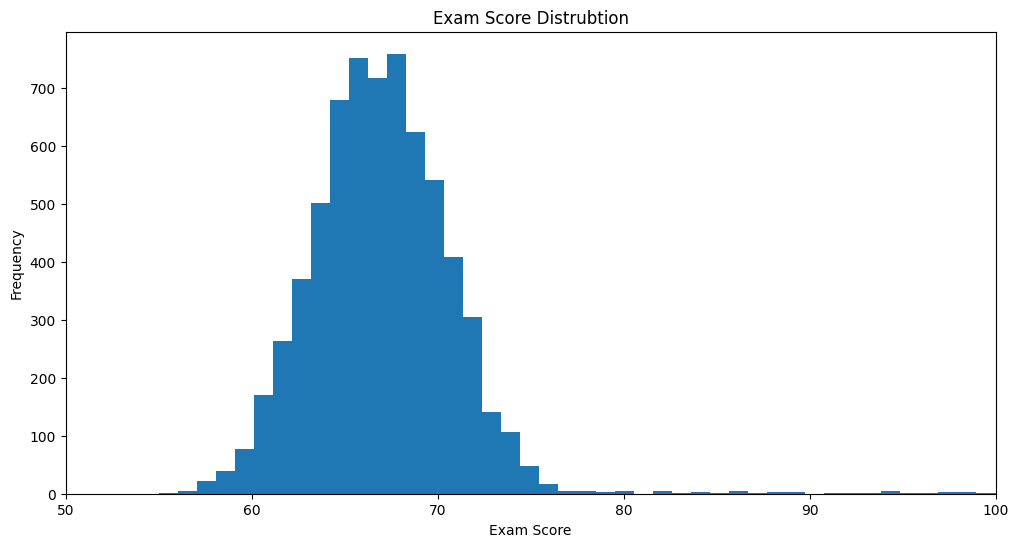

In [8]:
plt.figure(figsize=(12, 6))
plt.hist(dataset["Exam_Score"], bins=45)
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.title("Exam Score Distrubtion")
plt.xlim(50, 100)
plt.show()

The target variable (exam score) follows an approximately normal (Gaussian) distribution. Observed values range from 55 to 101, although the valid score range is expected to be 0–100. The value of 101 is therefore likely a data error or outlier and should be addressed during preprocessing.

Most observations are concentrated in the range of 60 to 75, with a peak around 68 (frequency exceeding 700). Values outside this interval are relatively rare, indicating low variance in the tails and a strong central tendency.

The distribution is unimodal and fairly symmetric, making it suitable for regression-based modeling approaches that assume normally distributed residuals.

**1.2.2 - Features**

**1.2.3 - Analysis of Hours Studied column**

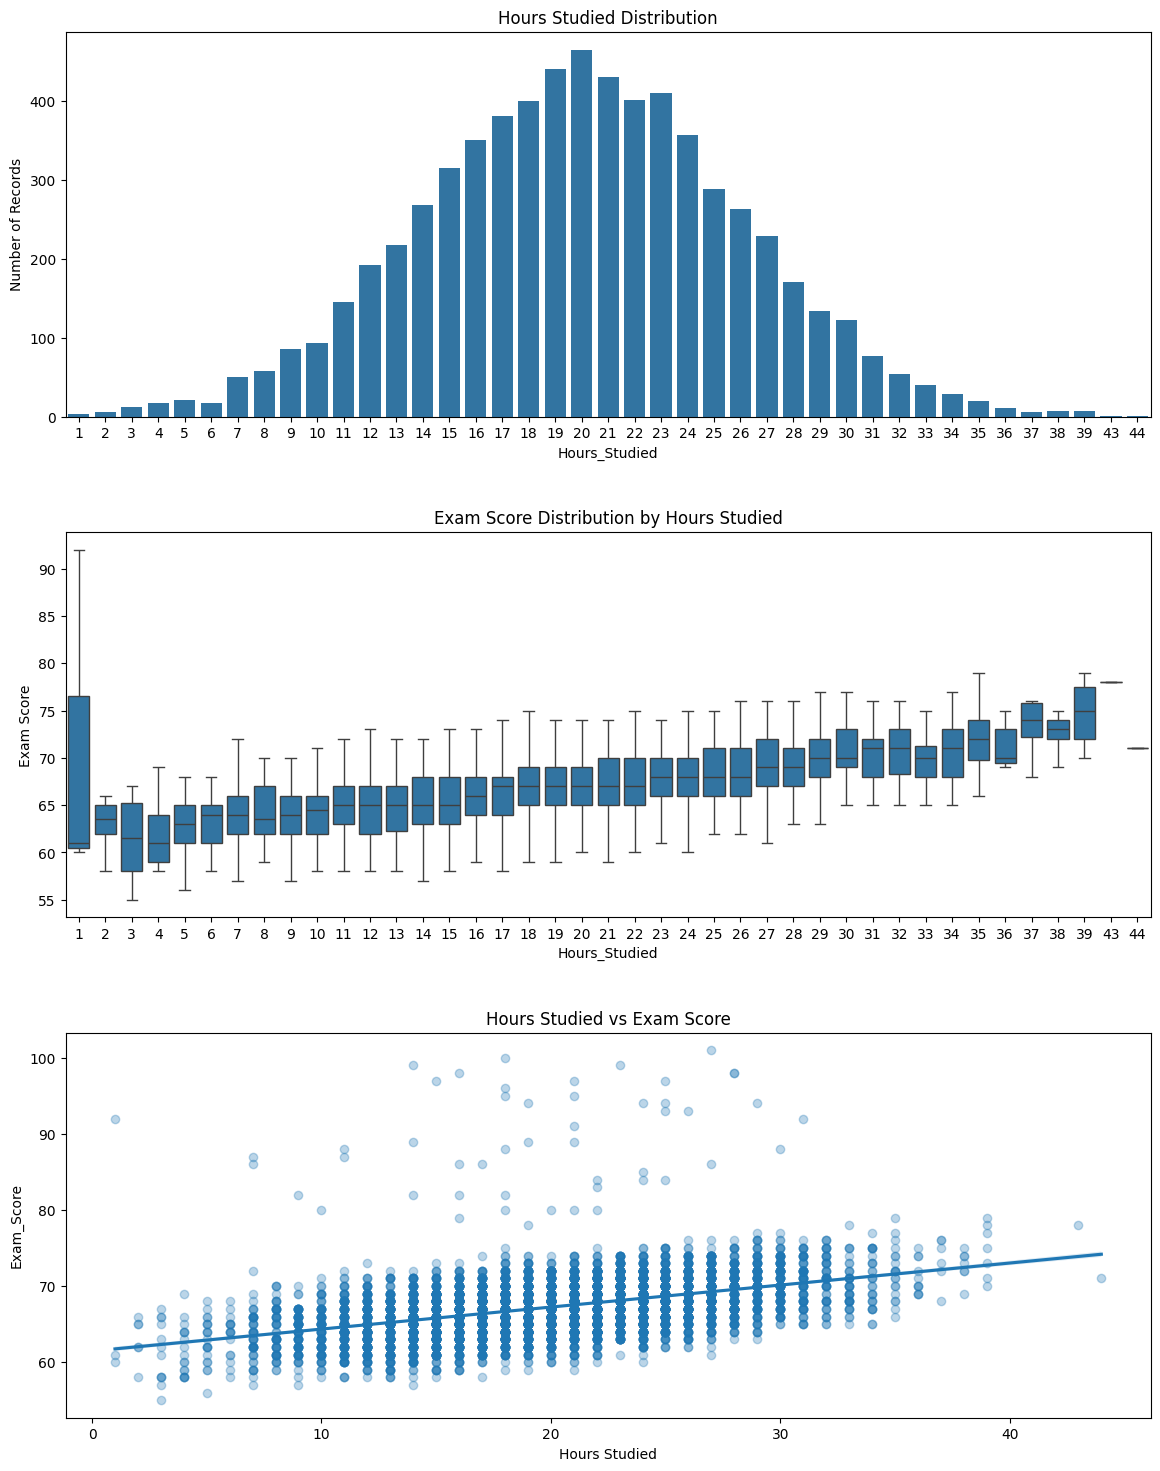

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(14, 18))
ax = ax.flatten()

sns.countplot(x="Hours_Studied", data=dataset, ax=ax[0])
ax[0].set_title("Hours Studied Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Hours_Studied", y="Exam_Score", data=dataset,
            ax=ax[1], showfliers=False)
ax[1].set_title("Exam Score Distribution by Hours Studied")
ax[1].set_ylabel("Exam Score")

sns.regplot(
    x="Hours_Studied",
    y="Exam_Score",
    data=dataset,
    ax=ax[2],
    scatter_kws={"alpha": 0.3}
)
ax[2].set_title("Hours Studied vs Exam Score")
ax[2].set_xlabel("Hours Studied")


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

The distribution of the Hours_Studied variable appears to be approximately normal, as the frequency of values resembles a bell-shaped curve.

When comparing Hours_Studied with exam scores, a clear positive relationship can be observed: as the number of hours studied increases, exam scores tend to increase as well. This suggests that study time is an important predictor of performance.

However, it is important to consider the presence of outliers, as they may distort the overall correlation and lead to misleading conclusions.

**1.2.4 - Analysis of Attendance column**

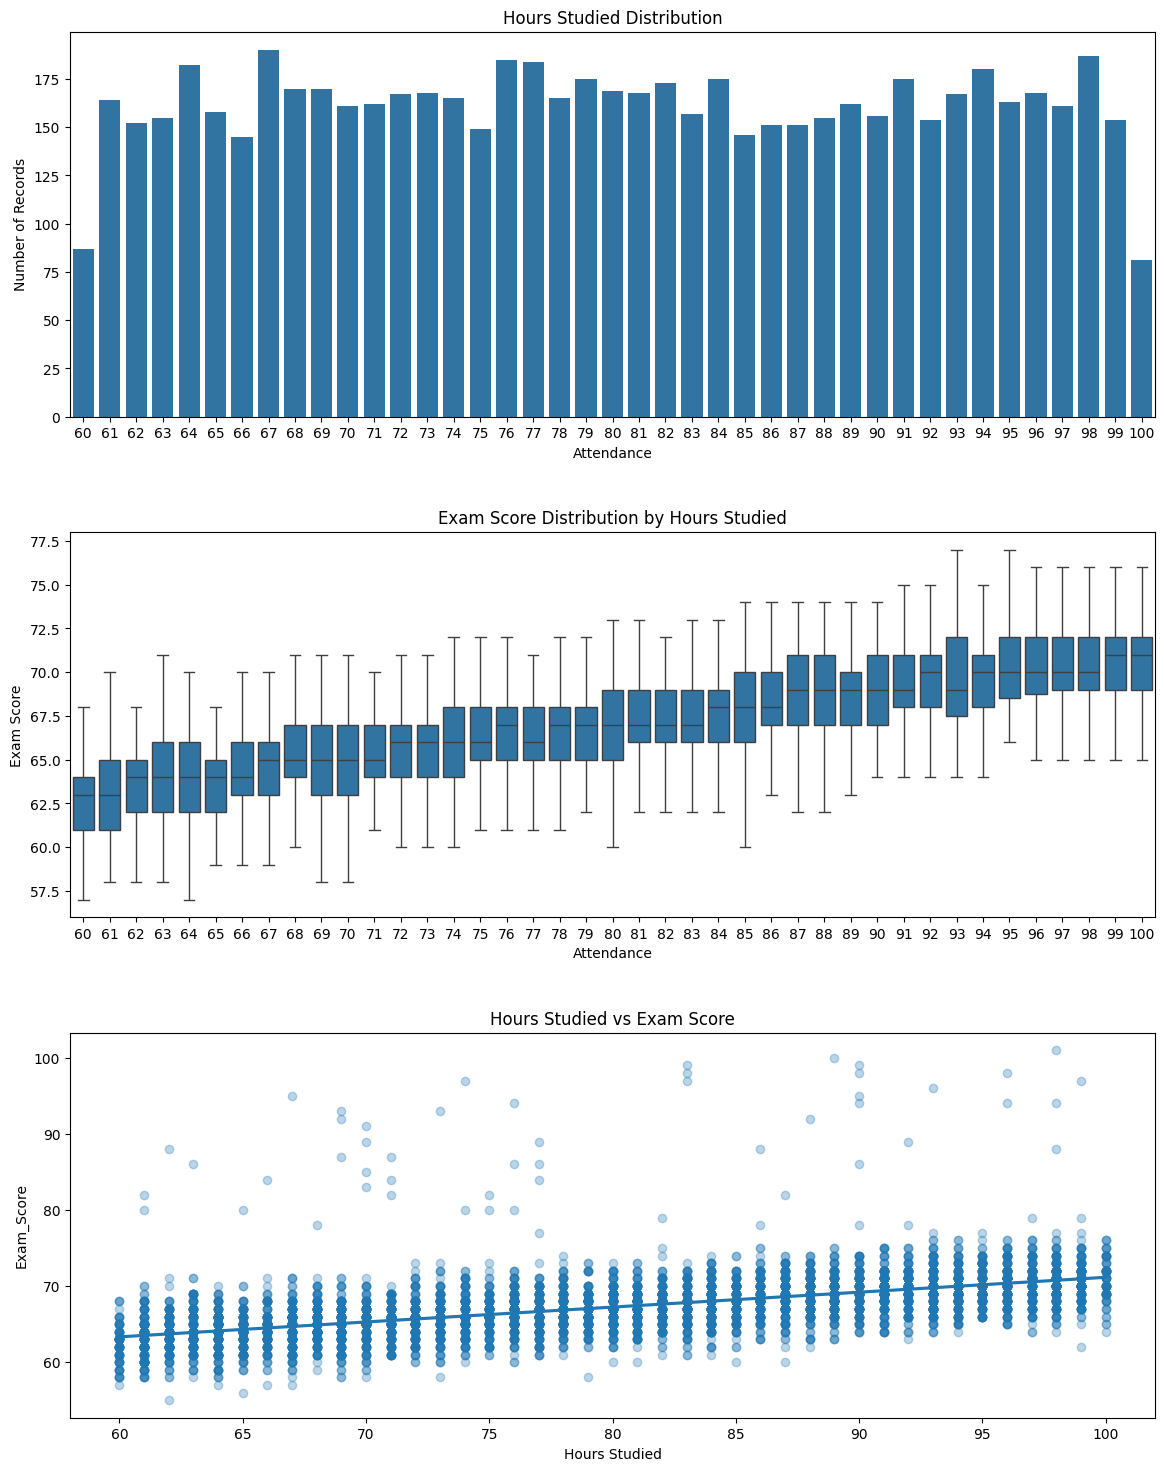

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(14, 18))
ax = ax.flatten()

sns.countplot(x="Attendance", data=dataset, ax=ax[0])
ax[0].set_title("Attendance Distribution")
ax[0].set_ylabel("Number of Records")

sns.boxplot(x="Attendance", y="Exam_Score", data=dataset,
            ax=ax[1], showfliers=False)
ax[1].set_title("Exam Score Distribution by Attendance")
ax[1].set_ylabel("Exam Score")

sns.regplot(
    x="Attendance",
    y="Exam_Score",
    data=dataset,
    ax=ax[2],
    scatter_kws={"alpha": 0.3}
)
ax[2].set_title("Attendance vs Exam Score")
ax[2].set_xlabel("Attendance")


plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()